# Codebook Visualisation

Loads a `*_codebook.npz` saved by the Hilbert VQ-VAE pipeline and plots the
descriptor of each **used** code.

- Codes are **reordered by usage** (most-used first) and **relabelled `A, B, C, ...`**
  (then `AA, AB, ...` beyond 26).
- **Amplitude** codebooks are shown as band x channel heatmaps.
- **Coherence / connectivity** codebooks are shown as channel x channel matrices,
  one figure per frequency band.

Set `CODEBOOK_NPZ` below to your file and run all cells.

In [19]:
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")

# ── point this at your saved codebook file ──
CODEBOOK_NPZ = "20220816_L_amplitude_K32_codebook.npz"    # <-- edit me
NCOLS        = 5      # columns in the plot grids

# -- channel names, in the SAME order as the descriptor channel axis --
# Needed only for scalp topomaps. Overridden by npz "channel_names" if present.
CHANNEL_NAMES = ['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
# Montage: an MNE built-in name (e.g. "standard_1020") resolves standard 10-20
# labels by name; for other caps give a montage file path MNE can read.
MONTAGE = "standard_1020"

## Load and order

Used codes (window count > 0) are sorted by usage, highest first, and given
letter labels `A, B, ... Z, AA, AB, ...`.

In [21]:
def code_labels(n):
    """A..Z, then AA, AB, ... ZZ."""
    out = []
    for i in range(n):
        if i < 26:
            out.append(string.ascii_uppercase[i])
        else:
            j = i - 26
            out.append(string.ascii_uppercase[j // 26] + string.ascii_uppercase[j % 26])
    return out

d           = np.load(CODEBOOK_NPZ, allow_pickle=True)
descriptor  = str(d["descriptor"])
counts      = d["counts"].astype(int)
n_filt      = int(d["n_filt"])
C           = int(d["n_channels"])
band_labels = [str(b) for b in d["band_labels"]]

# channel names: from the file if present, else the config list
if "channel_names" in d.files:
    channel_names = [str(c) for c in d["channel_names"]]
else:
    channel_names = list(CHANNEL_NAMES)
assert len(channel_names) == C, (
    f"CHANNEL_NAMES has {len(channel_names)} names but descriptor has C={C}")

# used codes, ordered by usage (desc), then relabelled A, B, C, ...
used   = np.where(counts > 0)[0]
order  = used[np.argsort(-counts[used], kind="stable")]
labels = code_labels(len(order))
label_of = {int(k): labels[i] for i, k in enumerate(order)}

print(f"descriptor : {descriptor}")
print(f"codebook   : {int(d['codebook_size'])} entries, {len(order)} used")
print(f"bands      : {band_labels}")
if "prune_pct" in d.files:
    print(f"prune_pct  : {float(d['prune_pct'])}%   "
          f"(surviving: {len(d['surviving_tokens'])}, pruned: {len(d['pruned_tokens'])})")

# usage summary table (ordered, relabelled)
print("\nlabel  orig_id  windows   % of used-window mass")
tot = counts[order].sum()
for i, k in enumerate(order):
    print(f"  {labels[i]:<4} {int(k):>6}   {int(counts[k]):>7}   {100*counts[k]/tot:>6.2f}%")

descriptor : amplitude
codebook   : 32 entries, 18 used
bands      : ['4-8Hz', '8-12Hz', '12-20Hz', '20-30Hz', '30-45Hz']
prune_pct  : 2.0%   (surviving: 18, pruned: 14)

label  orig_id  windows   % of used-window mass
  A         6        58     8.44%
  B        10        56     8.15%
  C        25        51     7.42%
  D        21        46     6.70%
  E         2        45     6.55%
  F         3        45     6.55%
  G         4        45     6.55%
  H         0        42     6.11%
  I        12        42     6.11%
  J        22        37     5.39%
  K        24        37     5.39%
  L         5        35     5.09%
  M        15        33     4.80%
  N        31        31     4.51%
  O        27        29     4.22%
  P        28        22     3.20%
  Q         1        17     2.47%
  R        29        16     2.33%


## Usage bar chart

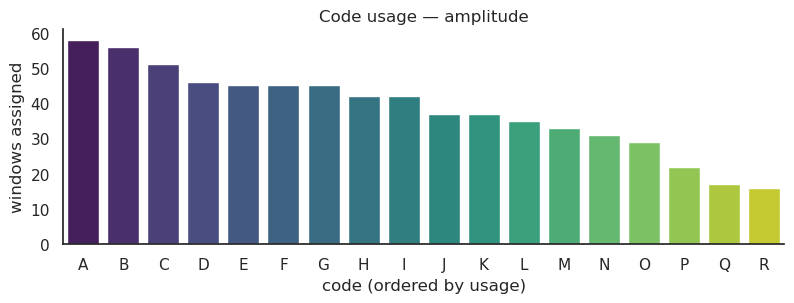

In [22]:
fig, ax = plt.subplots(figsize=(max(6, len(order)*0.45), 3.2))
sns.barplot(x=labels, y=counts[order], hue=labels, palette="viridis",
            legend=False, ax=ax)
ax.set_xlabel("code (ordered by usage)")
ax.set_ylabel("windows assigned")
ax.set_title(f"Code usage — {descriptor}")
sns.despine()
plt.tight_layout()
plt.show()

## Amplitude codes

Each panel is one code: rows are frequency bands, columns are EEG channels.
Only shown when the descriptor is `amplitude`.

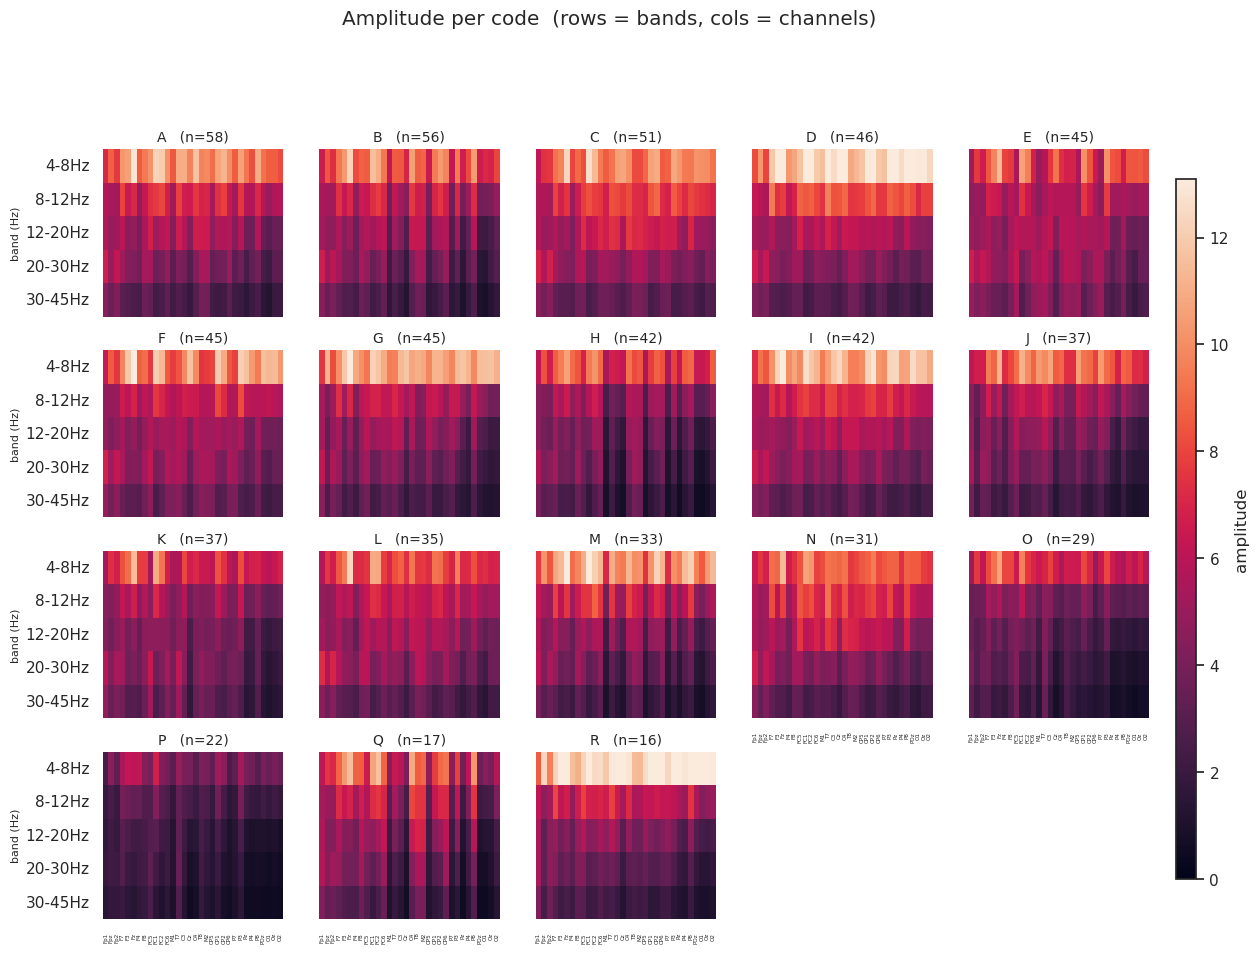

In [23]:
if descriptor == "amplitude":
    amp = d["amplitude_maps"]                      # (K, n_filt, C)
    vmax = np.percentile(amp[order], 99)
    ncol = min(NCOLS, len(order))
    nrow = int(np.ceil(len(order) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*2.7, nrow*2.5), squeeze=False)
    for i, k in enumerate(order):
        ax = axes[i // ncol][i % ncol]
        on_bottom = (i // ncol == nrow - 1) or (i + ncol >= len(order))
        sns.heatmap(amp[k], ax=ax, cmap="rocket", vmin=0, vmax=vmax, cbar=False,
                    xticklabels=(channel_names if on_bottom else False),
                    yticklabels=(band_labels if i % ncol == 0 else False))
        if on_bottom:
            ax.set_xticklabels(channel_names, fontsize=4, rotation=90)
        ax.set_title(f"{labels[i]}   (n={int(counts[k])})", fontsize=10)
        if i % ncol == 0:
            ax.set_ylabel("band (Hz)", fontsize=8)
    for j in range(len(order), nrow*ncol):
        axes[j // ncol][j % ncol].axis("off")
    # one shared colourbar in its own axis
    fig.subplots_adjust(right=0.90)
    cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap="rocket",
                               norm=plt.Normalize(vmin=0, vmax=vmax))
    fig.colorbar(sm, cax=cax, label="amplitude")
    fig.suptitle("Amplitude per code  (rows = bands, cols = channels)", y=1.02)
    plt.show()
else:
    print(f"descriptor is '{descriptor}', not amplitude — see the connectivity section below.")

## Coherence / connectivity codes

Channel x channel matrices, capped at `COH_VMAX`. Set `CONN_LAYOUT` to choose the
layout:

- `"by_band"` — one figure per frequency band, each panel a different code
  (compare codes within a band).
- `"by_code"` — one figure per code, each panel a different band
  (see how one microstate's connectivity changes across frequency).

`BAND_IDX` / `CODE_LABEL` pick which single band or code the first cell shows; the
"all" cell renders the full set in the chosen layout.

In [26]:
# ── connectivity display options ──
CONN_LAYOUT    = "by_code"   # "by_band": one figure per band, all codes
                             # "by_code": one figure per code, all bands
BAND_IDX       = 0           # which band to show in the single "by_band" cell below
CODE_LABEL     = "A"         # which code to show in the single "by_code" cell below
COH_VMAX       = 0.7         # colour-scale cap for connectivity matrices
PANELS_PER_ROW = 3           # matrices per row; fewer = bigger panels

_conn_cmap = "rocket" if descriptor in ("coherence") else "RdBu_r"

def _grid(n):
    ncol = min(PANELS_PER_ROW, n)
    nrow = int(np.ceil(n / ncol))
    return ncol, nrow

def _draw(ax, mat, title):
    sns.heatmap(mat, ax=ax, cmap=_conn_cmap, vmin=0.0, vmax=COH_VMAX,
                cbar=True, cbar_kws={"shrink": 0.8, "label": descriptor},
                square=True, xticklabels=channel_names, yticklabels=channel_names)
    ax.set_xticklabels(channel_names, fontsize=6, rotation=90)
    ax.set_yticklabels(channel_names, fontsize=6, rotation=0)
    ax.set_title(title, fontsize=13)

def plot_connectivity_band(band_idx):
    """One figure: every code's matrix for a single band."""
    mats = d["connectivity_matrices"]                    # (K, n_filt, C, C)
    ncol, nrow = _grid(len(order))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*5.2, nrow*5.2), squeeze=False)
    for i, k in enumerate(order):
        _draw(axes[i // ncol][i % ncol], mats[k, band_idx],
              f"{labels[i]}   (n={int(counts[k])})")
    for j in range(len(order), nrow*ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.suptitle(f"{descriptor} per code — band {band_labels[band_idx]} Hz "
                 f"(channel x channel, capped at {COH_VMAX})", y=1.005, fontsize=14)
    fig.tight_layout(); plt.show()

def plot_connectivity_code(code_label):
    """One figure: a single code's matrix for every band."""
    mats = d["connectivity_matrices"]
    if code_label not in labels:
        print(f"code {code_label!r} not among used codes: {labels}"); return
    k = int(order[labels.index(code_label)])
    ncol, nrow = _grid(n_filt)
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*5.2, nrow*5.2), squeeze=False)
    for b in range(n_filt):
        _draw(axes[b // ncol][b % ncol], mats[k, b], f"{band_labels[b]} Hz")
    for j in range(n_filt, nrow*ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.suptitle(f"{descriptor} — code {code_label} (n={int(counts[k])}) "
                 f"across bands (channel x channel, capped at {COH_VMAX})",
                 y=1.005, fontsize=14)
    fig.tight_layout(); plt.show()

if descriptor == "amplitude":
    print("descriptor is amplitude — use the amplitude section above.")
elif CONN_LAYOUT == "by_band":
    plot_connectivity_band(BAND_IDX)
elif CONN_LAYOUT == "by_code":
    plot_connectivity_code(CODE_LABEL)
else:
    print(f"unknown CONN_LAYOUT {CONN_LAYOUT!r}; use 'by_band' or 'by_code'.")

descriptor is amplitude — use the amplitude section above.


### All bands / all codes

Renders the full set according to `CONN_LAYOUT`: one figure per **band** (each showing all codes) if `by_band`, or one figure per **code** (each showing all bands) if `by_code`.

In [27]:
if descriptor == "amplitude":
    print("descriptor is amplitude — nothing to loop over.")
elif CONN_LAYOUT == "by_band":
    for b in range(n_filt):
        plot_connectivity_band(b)
elif CONN_LAYOUT == "by_code":
    for lab in labels:
        plot_connectivity_code(lab)
else:
    print(f"unknown CONN_LAYOUT {CONN_LAYOUT!r}; use 'by_band' or 'by_code'.")

descriptor is amplitude — nothing to loop over.


## Amplitude scalp topomaps

Scalp projections of each amplitude code, one row per code (usage order), one column per band. Sensor positions come from `CHANNEL_NAMES` via `MONTAGE`. 

*(Topomaps apply to amplitude, a per-channel quantity. Coherence is a channel-by-channel quantity, shown as matrices above; a scalp view of coherence needs a connectivity layout such as a head-with-edges plot, not a single-value topomap.)*

In [28]:
import mne
mne.set_log_level("ERROR")

def make_info(channel_names, montage):
    info = mne.create_info(channel_names, sfreq=1000.0, ch_types="eeg")
    try:
        info.set_montage(montage, on_missing="warn")
    except Exception as e:
        print(f"Could not set montage {montage!r}: {e}")
    return info

if descriptor == "amplitude":
    _info = make_info(channel_names, MONTAGE)
    _pos = _info.get_montage().get_positions()["ch_pos"]
    _missing = [c for c in channel_names
                if c not in _pos or not np.all(np.isfinite(list(_pos[c])))]
    if _missing:
        print(f"WARNING: no scalp position for {_missing} - they read as blank.")
    else:
        print(f"All {len(channel_names)} channels placed on {MONTAGE!r}.")
else:
    print(f"descriptor is {descriptor!r} - topomaps apply to amplitude only.")

All 32 channels placed on 'standard_1020'.


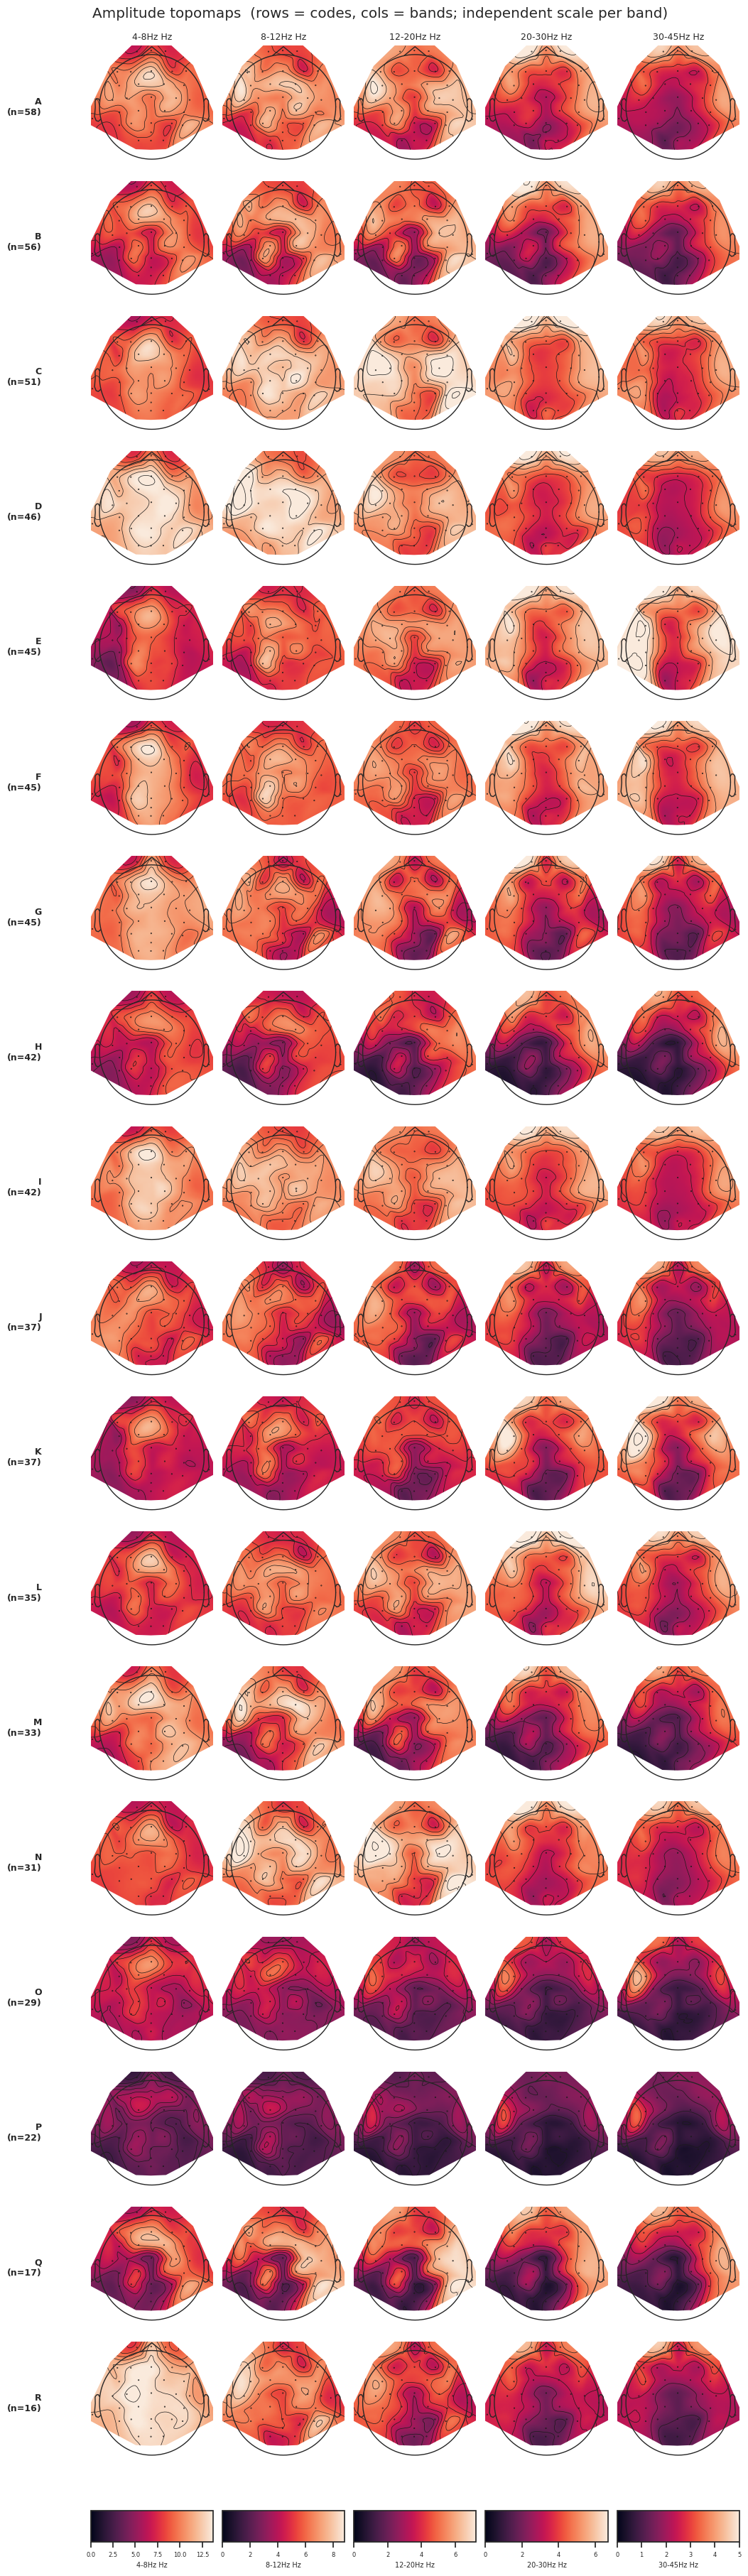

In [29]:
if descriptor == "amplitude":
    amp    = d["amplitude_maps"]                       # (K, n_filt, C)
    rocket = sns.color_palette("rocket", as_cmap=True)
    # INDEPENDENT scale per band: each band gets its own vmax from its own data,
    # so low-amplitude high-frequency bands are not washed out by the low bands.
    band_vmax = [float(np.percentile(amp[order, b], 99)) for b in range(n_filt)]
    band_vmax = [v if v > 0 else 1.0 for v in band_vmax]

    nrow = len(order)
    # extra bottom space for one horizontal colourbar under each band column
    fig, axes = plt.subplots(nrow, n_filt, figsize=(n_filt*2.1, nrow*2.0 + 0.8),
                             squeeze=False)
    ims = [None] * n_filt
    for r, k in enumerate(order):
        for b in range(n_filt):
            ax = axes[r][b]
            ims[b], _ = mne.viz.plot_topomap(amp[k, b], _info, axes=ax, show=False,
                                             cmap=rocket, vlim=(0, band_vmax[b]),
                                             contours=6, extrapolate="local")
            if r == 0:
                ax.set_title(f"{band_labels[b]} Hz", fontsize=9)
        axes[r][0].text(-0.4, 0.5, f"{labels[r]}\n(n={int(counts[k])})",
                        transform=axes[r][0].transAxes, fontsize=9,
                        va="center", ha="right", weight="bold")

    # leave room at the bottom, then add one horizontal colourbar per column,
    # aligned under that column, each with its own band-specific scale
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    for b in range(n_filt):
        pos = axes[nrow-1][b].get_position()       # bottom panel of column b
        cax = fig.add_axes([pos.x0, 0.035, pos.width, 0.012])
        cb = fig.colorbar(ims[b], cax=cax, orientation="horizontal")
        cb.ax.tick_params(labelsize=6)
        cb.set_label(f"{band_labels[b]} Hz", fontsize=7)
    fig.suptitle("Amplitude topomaps  (rows = codes, cols = bands; "
                 "independent scale per band)", y=1.005)
    plt.show()
else:
    print("Topomaps apply to amplitude only.")